In [1]:
%load_ext autoreload
%autoreload 2

import sys
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from IPython.display import display

# Ensure the notebook can find the /src directory
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [2]:
from src.data_loader import VesselDataLoader
from src.visualizer import (
    plot_block_space, 
    plot_mode_statistics, 
    plot_series,
    plot_scenario_tradeoff_space,
    plot_trajectory_folium
)
from src.data_processing import engineer_telemetry_features
from src.mission_profiler import MissionProfiler, ScenarioManager

In [3]:
filenames = ["Wembley_voy_236.csv" ,"Rotherhithe_voy_179.csv"]
raw_data_cache = {}

# Load data into memory once
for filename in filenames:
    print(f"Ingesting {filename} into memory...")
    raw_data_file = root_path / "data" / "raw" / filename
    loader = VesselDataLoader(raw_data_file)
    raw_data_cache[filename] = loader.load_and_clean()

Ingesting Wembley_voy_236.csv into memory...
Ingesting Rotherhithe_voy_179.csv into memory...



Processing default features for Wembley_voy_236.csv...
  -> Worst-Case Causal Power Peak Required: 0.0 kW
  -> Min Energy Capacity Excursion Integral: 0.0 kWh


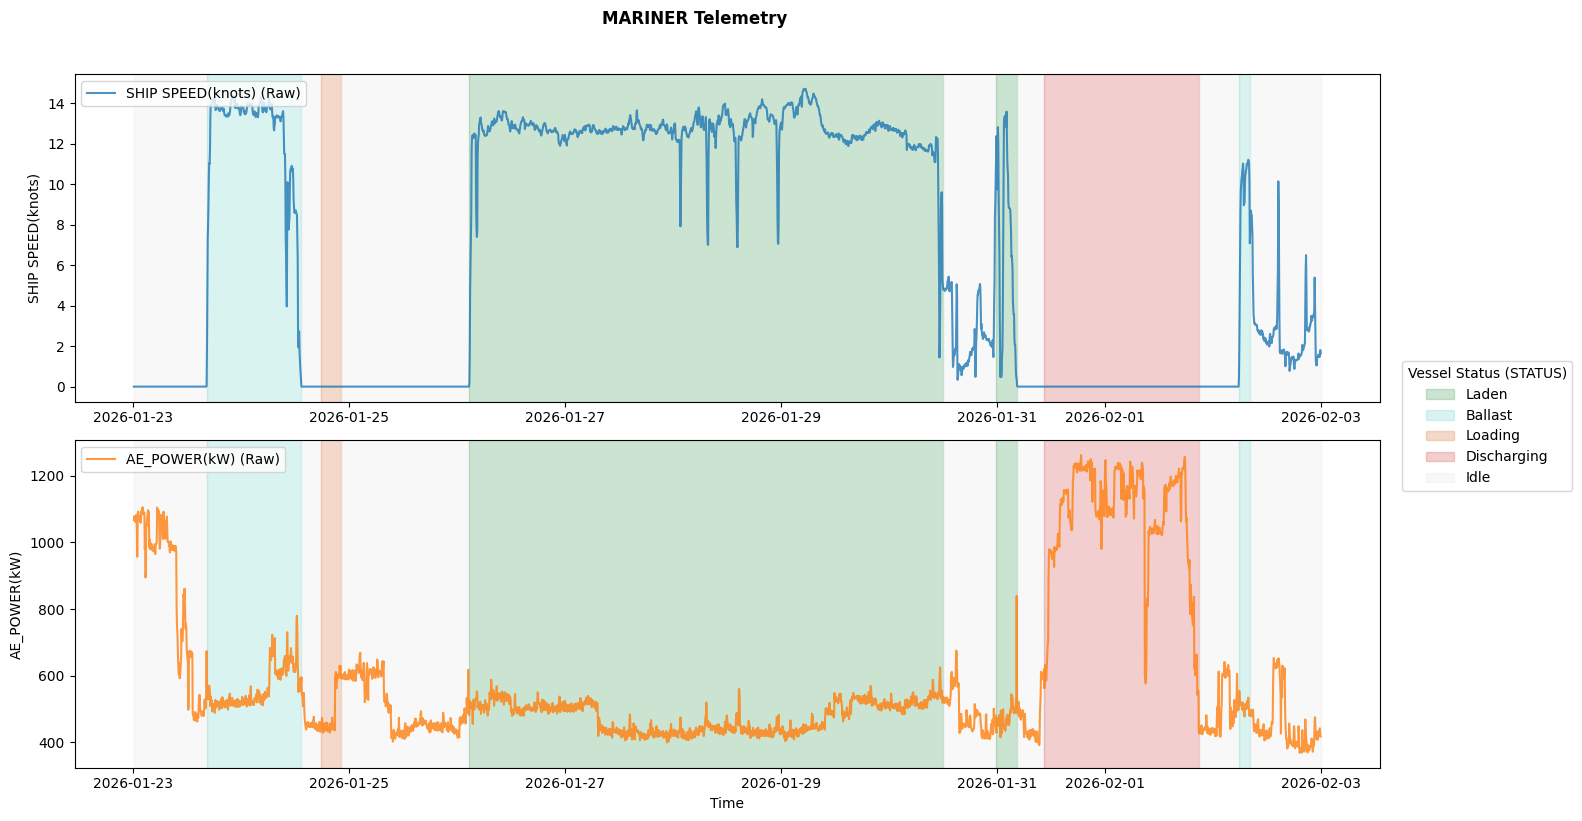


Processing default features for Rotherhithe_voy_179.csv...
  -> Worst-Case Causal Power Peak Required: 0.0 kW
  -> Min Energy Capacity Excursion Integral: 0.0 kWh


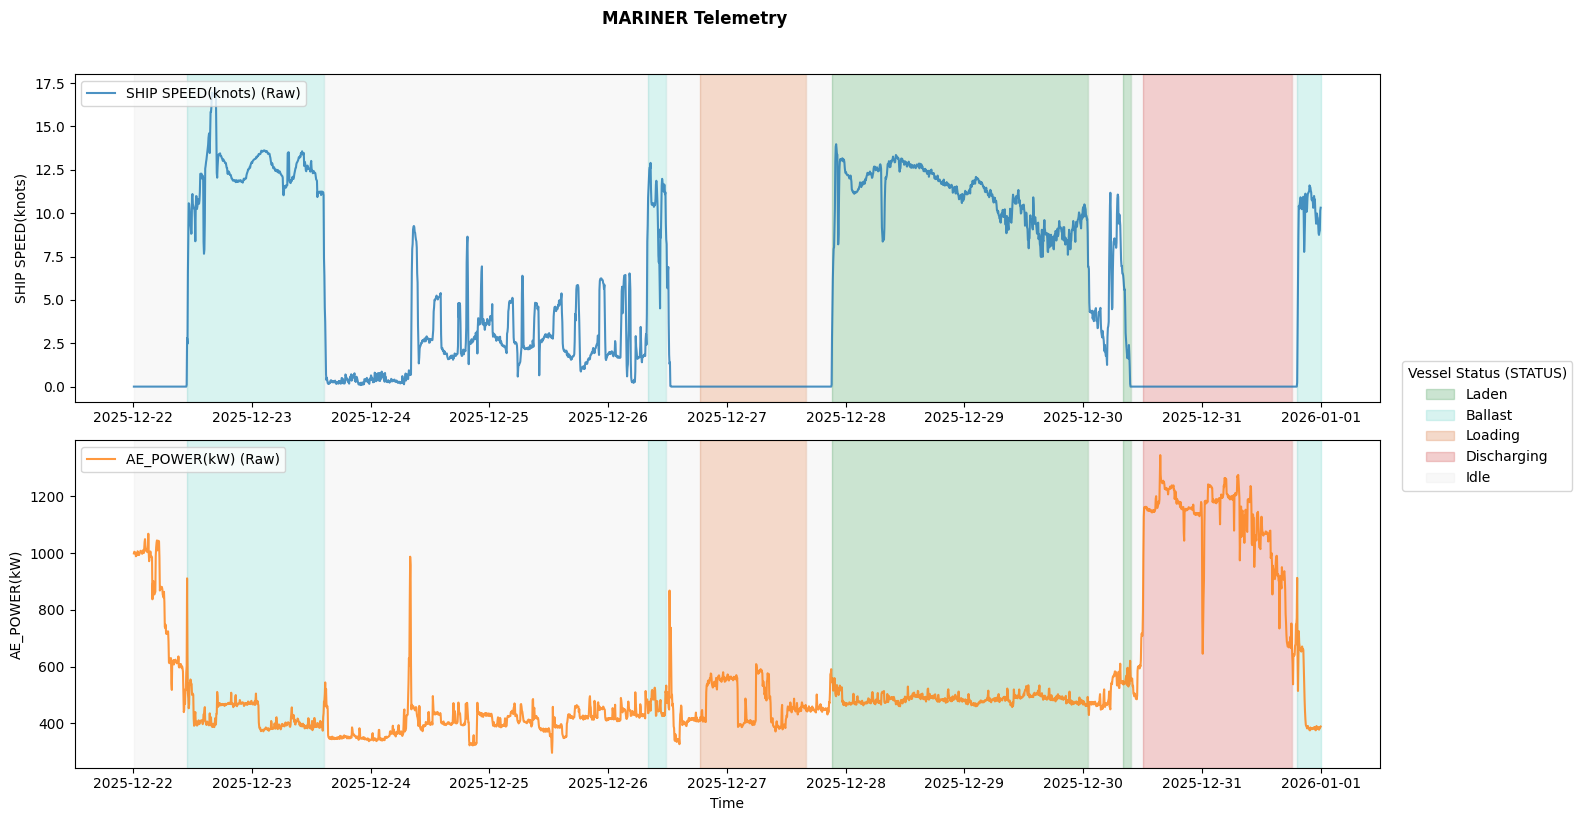

In [8]:
filtered_registry_entries = []
profiler = MissionProfiler(speed_threshold=1.0)

for filename, raw_df in raw_data_cache.items():
    print(f"\nProcessing default features for {filename}...")
    
    # Applying low-pass filtering automatically computes the inline battery specs
    filtered_df = engineer_telemetry_features(raw_df, filter_method='raw')
    
    # Inspect battery limits for the hardware envelope tracking
    battery_metrics = filtered_df.attrs.get('battery_specs', {})
    print(f"  -> Worst-Case Causal Power Peak Required: {battery_metrics.get('worst_case_power_peak_kW', 0.0):.1f} kW")
    print(f"  -> Min Energy Capacity Excursion Integral: {battery_metrics.get('min_capacity_excursion_kWh', 0.0):.1f} kWh")
    
    # Generate Low-Pass Filtered Block Registries (Target Architecture Base)
    filtered_registry_df = profiler.generate_block_registry(
        filtered_df, 
        source_file_name=filename, 
        merge_loitering=False, 
        unify_port_ops=False
    )
    filtered_registry_entries.append(filtered_registry_df)
    
    # Standard validation diagnostic visualizations
    fig, axes = plot_series(filtered_df, ['SHIP SPEED(knots)','AE_POWER(kW)'],subplots=True)
    plt.show() 
    display(plot_trajectory_folium(filtered_df))

# Concatenate all blocks and generate mathematically consistent global stats
combined_filtered_registry = pd.concat(filtered_registry_entries, ignore_index=True)
combined_filtered_stats = profiler.extract_global_statistics(combined_filtered_registry)

In [5]:
cutoff_presets = [0.40, 0.20, 0.10, 0.05, 0.02, 0.01]

# NOTE: Updated to standard lowercase mode names
evaluation_runs = {
    "Full Spectrum": [],
    "Transit & Maneuvering Only": ['port_loading', 'port_unloading']
}

for filename, raw_df in raw_data_cache.items():
    print(f"\n{'='*30}\nBATTERY PARAMETER SWEEP: {filename}\n{'='*30}")
    
    # Build the structural baseline strictly from memory
    raw_features_df = engineer_telemetry_features(raw_df.copy(), filter_method='raw')
    base_classified = profiler.classify_modes(raw_features_df)
    base_classified['STATUS'] = base_classified['MODE']

    for run_name, ignore_list in evaluation_runs.items():
        print(f"\n--- CONFIGURATION: {run_name} ---")
        battery_sweep_records = []
        
        for fc in cutoff_presets:
            sweep_filtered_df = engineer_telemetry_features(
                base_classified, 
                filter_method='butter', 
                cutoff=fc, 
                ignore_modes=ignore_list
            )
            
            specs = sweep_filtered_df.attrs.get('battery_specs', {})
            if specs:
                installed_capacity_buffer_60pc = specs['min_capacity_excursion_kWh'] / 0.60
                battery_sweep_records.append({
                    'Cutoff (fc)': fc,
                    'Max Inverter (kW)': round(specs['worst_case_power_peak_kW'], 1),
                    'Min Usable (kWh)': round(specs['min_capacity_excursion_kWh'], 1),
                    'Est Pack (kWh)': round(installed_capacity_buffer_60pc, 1)
                })
        
        print(pd.DataFrame(battery_sweep_records).to_string(index=False))


BATTERY PARAMETER SWEEP: Wembley_voy_236.csv

--- CONFIGURATION: Full Spectrum ---
 Cutoff (fc)  Max Inverter (kW)  Min Usable (kWh)  Est Pack (kWh)
        0.40              261.7            1781.1          2968.5
        0.20              261.7            1781.2          2968.7
        0.10              295.0            1769.6          2949.4
        0.05              357.2            1745.6          2909.4
        0.02              423.2            1769.3          2948.8
        0.01              423.2            2208.8          3681.3

--- CONFIGURATION: Transit & Maneuvering Only ---
 Cutoff (fc)  Max Inverter (kW)  Min Usable (kWh)  Est Pack (kWh)
        0.40              179.7             186.1           310.1
        0.20              253.3             180.9           301.5
        0.10              295.0             176.1           293.4
        0.05              314.6             191.7           319.6
        0.02              354.8             270.2           450.3
       

In [6]:
# 1. Plot Block Workspace
fig_bricks_fatigue = plot_block_space(combined_filtered_registry, y_axis_metric='Relative_Fatigue_Activity_Rate')
fig_bricks_fatigue.show()

# 2. Plot Aggregated Mode Statistics
fig_stats_fatigue = plot_mode_statistics(combined_filtered_stats, y_axis_metric='Relative_Fatigue_Activity_Rate', print_summary=True)
fig_stats_fatigue.show()

# 3. Instantiate Scenario Manager & Run Pipeline
manager = ScenarioManager(registry_df=combined_filtered_registry, global_stats=combined_filtered_stats)
compiled_scenario_outputs = manager.run_full_scenario_pipeline(total_target_h=1000.0, print_summary=True)

# 4. Render Final Scenario Optimization Tradeoff Chart
fig_tradeoff = plot_scenario_tradeoff_space(compiled_scenario_outputs)
fig_tradeoff.show()


--- Operational State Statistics Summary ---
               Mode  Time Fraction (%)  Avg Block Duration (h)  Mean Power (kW)  Mean H2 Rate (kg/h)  Fatigue Damage Rate (/h)  Power Fluctuation  Mean Ship Speed (kn)
          port_idle              13.93                    15.8            490.3                29.73                    0.1063               1.62                  0.08
       port_loading               5.71                    13.0            480.4                29.13                    0.0843               1.42                  0.00
     port_unloading              14.21                    32.2            971.1                58.88                    0.1259               2.60                 -0.00
      sea_loitering              18.62                    28.2            424.2                25.72                    0.0517               0.85                  2.72
sea_transit_ballast              11.57                    26.2            484.1                29.35              

  Scenario Profile         Data Strategy  Energy Demanded (kWh)  \
0         Baseline      Full Run Average               541713.1   
1         Baseline  Bottom 25% Optimized               522992.2   
2      Shore_Power      Full Run Average               473957.4   
3      Shore_Power  Bottom 25% Optimized               446717.2   
4   PEMFC_Off_Port      Full Run Average               469896.4   
5   PEMFC_Off_Port  Bottom 25% Optimized               447795.0   
6       Long_Trips      Full Run Average               541368.7   
7       Long_Trips  Bottom 25% Optimized               528245.1   

   H2 Mass Min [η=0.55] (kg)  H2 Mass Max [η=0.45] (kg)  Fatigue Index  \
0                    29559.8                    36128.7       54.21242   
1                    28538.3                    34880.1       66.74865   
2                    25862.6                    31609.8       52.68654   
3                    24376.1                    29793.1       60.17274   
4                    25641